Интернет магазин одежды решил изменить дизайн карточки товара. В тестовой версии добавили блок с отзывами под ценой, а в контрольной — ничего не изменяли. Каждая выборка состоит из 1000 человек.</br>
Проверить, влияет ли изменение дизайна на конверсию.

Нулевая гипотеза: конверсия в группах A и B не отличается.</br>
Альтернативная гипотеза: конверсия в группе B выше чем в A.</br>
Уровень значимости 5%.

In [1]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
from matplotlib import pyplot as plt

In [2]:
p_control = 0.08 #Конверсия в контрольной группе
p_test = 0.1 #Конверсия в тестовой группе

#Генерация данных
np.random.seed(0)

control_group = np.random.choice([0,1], size=1000, p=[1-p_control, p_control])
test_group = np.random.choice([0,1], size=1000, p=[1-p_test, p_test])

#Конверсия для выборок
conversion_control = np.mean(control_group)
conversion_test = np.mean(test_group)

n_control = len(control_group)
n_test = len(test_group)

print(f'Конверсия в контрольной группе: {conversion_control:.1%}')
print(f'Конверсия в тестовой группе: {conversion_test:.1%}')

#Строим ДИ A
z_crit = 1.96
se = np.sqrt(conversion_control*(1-conversion_control)/n_control)
margin_a = z_crit*se

lower_bound_a = conversion_control - margin_a
upper_bound_a = conversion_control + margin_a

print(f'ДИ-контрольная: [{lower_bound_a:.2%}, [{upper_bound_a:.2%}]')

#Строим ДИ B
z_crit = 1.96
se = np.sqrt(conversion_test*(1-conversion_test)/n_test)
margin_b = z_crit*se

lower_bound_b = conversion_test - margin_b
upper_bound_b = conversion_test + margin_b

print(f'ДИ-тестовая: [{lower_bound_b:.2%}, [{upper_bound_b:.2%}]')

Конверсия в контрольной группе: 9.2%
Конверсия в тестовой группе: 12.0%
ДИ-контрольная: [7.41%, [10.99%]
ДИ-тестовая: [9.99%, [14.01%]


In [3]:
count, ns = [np.sum(test_group), np.sum(control_group)], [len(test_group), len(control_group)]

z_stat, p_value = proportions_ztest(count, ns, alternative='larger')
print(f'z-stat: {z_stat:.2f}')
print(f'p-value: {p_value:.2f}')

z-stat: 2.03
p-value: 0.02


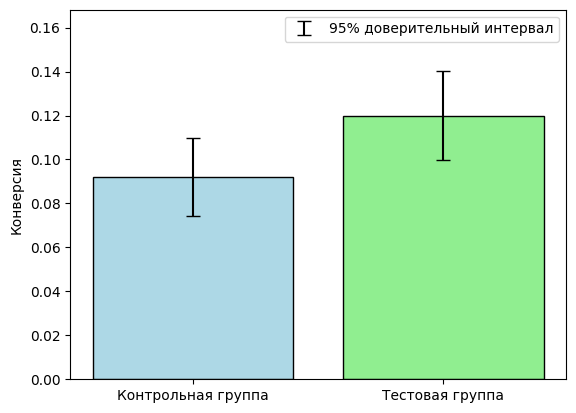

In [4]:
groups = ['Контрольная группа','Тестовая группа']
conversions = [conversion_control,conversion_test]
lower_bounds = [lower_bound_a, lower_bound_b]
upper_bounds = [upper_bound_a, upper_bound_b]

yerr = [conversions[0] - lower_bounds[0], conversions[1] - lower_bounds[1]]

plt.bar(groups, conversions, color=['lightblue', 'lightgreen'], capsize=5, edgecolor='black')

plt.errorbar( groups, conversions, yerr=yerr, capsize=5, color='black', label='95% доверительный интервал', fmt='none')

plt.ylabel('Конверсия')
plt.ylim(0,max(upper_bounds)*1.2)

plt.legend()
plt.show()

Конверсия в контрольной группе составила 9.2% [7.41%, [10.99%], в тестовой группе: 12.0% [9.99%, [14.01%]. Интервалы между собой практически не пересекаются, что указывает на статистическую значимость отличия.</br>
Z-stat (2.03) > 1.96, между тестовой и контрольной группой существует статистически значимая разница.</br>
На основании того, что z-stat положительное — делаем вывод что конверсия во второй группе выше, тестовая группа показала результаты лучше контрольной.</br>
Полученное значение p=0.02 (меньше порога 0.05).</br>

Разница между группами статистически значимая, нулевая гипотеза отклонена. Изменение дизайна привелок к увеличению конверсии, предлагаем внедрить изменения.